# Chaîne OSF CAPC-AC — Notebook 03 · Température et NMME (fin de la phase P1)

**Objectif :** compléter la base de données de la chaîne avec la **température** (observée et prévue) et avec le second système de prévision, **NMME**.

| Exigence du Draft Framework | Où dans ce notebook |
|---|---|
| §3.1.4 Jeux de référence : ERA5 pour la température | section 1 |
| §3.1.7 Grille commune avant tout calcul de biais | section 2 |
| §3.6.2 Produits de température au-delà de la moyenne : Tmax et Tmin | sections 1 et 3 |
| §3.2 Utiliser toute la période de hindcast disponible | section 4 (NMME depuis 1982) |
| D13 Seuils de température = percentiles extrêmes par point de grille | section 1 |

Les calculs sont faits par les étapes opérationnelles `OP_04` (référence ERA5), `OP_05` (températures C3S) et `OP_06` (NMME). Ce notebook relit leurs résultats et les explique.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(REPO)
from eccas_s2s.settings import load_cycle
from eccas_s2s.core.periods import build_periods
from eccas_s2s.obs.climatology import obs_period_totals, normals_for_periods
from eccas_s2s.obs.regrid import conservative_to_degree, match_model_grid
from eccas_s2s.operations import obs_era5, obs_chirps, c3s_totals, nmme_totals
from eccas_s2s.viz.maps import map_panel

cfg = load_cycle("config/cycle_202609.yaml")
SHP = cfg.raw["paths"]["shapefile"]
MODELS = list(cfg.c3s_models)
LABEL = {c: m.label for c, m in cfg.c3s_models.items()}

## 1. La référence observée de température : ERA5

### Pourquoi ne pas utiliser le fichier Tmin/Tmax existant

Le fichier ERA5 `mx2t`/`mn2t` disponible au CAPC-AC contient, malgré son pas de temps journalier, les extrêmes de **la seule heure précédant 00 UTC**, et non ceux de la journée. Sur l'ensemble du domaine en 2020, l'écart Tmax − Tmin y vaut **0,44 °C** en moyenne, alors qu'une amplitude diurne réaliste en Afrique centrale est de 8 à 13 °C. Son « Tmax » est même inférieur à la température moyenne du mois.

### Ce que la chaîne utilise

La T2m **horaire** d'ERA5 (0,25°) est téléchargée année par année, puis la moyenne, le maximum et le minimum de chaque **jour UTC** sont calculés localement à partir des 24 valeurs. Le jour UTC est aussi celui des champs C3S `maximum/minimum_2m_temperature_in_the_last_24_hours` : modèle et observation couvrent donc les mêmes heures.

In [2]:
qc = pd.read_csv(obs_era5.derived_paths(cfg)["qc"])
print(f"{len(qc)} lignes de contrôle (mois × variable), {qc.year.min()}–{qc.year.max()}")
pd.Series({
    "mois incomplets": int((qc.days_present != qc.days_expected).sum()),
    "valeurs manquantes": int(qc.missing_values.sum()),
    "valeurs hors plage −15…60 °C": int(qc.outside_range.sum()),
    "minimum absolu (°C)": round(float(qc["min"].min()), 1),
    "maximum absolu (°C)": round(float(qc["max"].max()), 1),
}).to_frame("bilan")

1644 lignes de contrôle (mois × variable), 1981–2026


,bilan
mois incomplets,0.0
valeurs manquantes,0.0
valeurs hors plage −15…60 °C,0.0
minimum absolu (°C),-9.2
maximum absolu (°C),48.6


amplitude diurne moyenne à N'Djamena : 12.8 °C


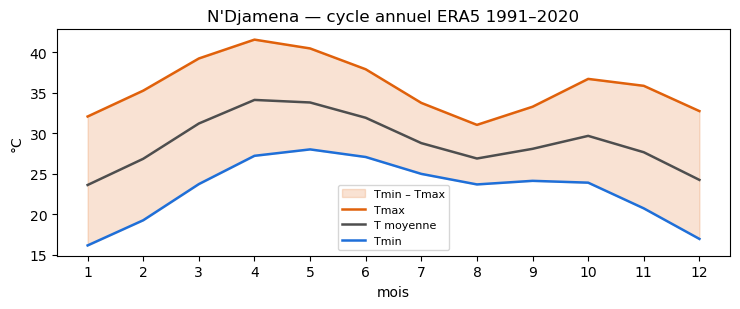

In [3]:
dek, mon = obs_era5.load_archives(cfg, "0p25")
pt = dict(latitude=12.13, longitude=15.05, method="nearest")   # N'Djamena
clim = mon.sel(time=slice("1991", "2020")).sel(**pt).groupby("time.month").mean()
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.fill_between(clim.month, clim.tmin, clim.tmax, color="#E0610B", alpha=0.18, label="Tmin – Tmax")
for v, c, lb in (("tmax", "#E0610B", "Tmax"), ("tmean", "#4E4E4E", "T moyenne"), ("tmin", "#1E6FD9", "Tmin")):
    ax.plot(clim.month, clim[v], color=c, lw=1.8, label=lb)
ax.set_xticks(range(1, 13)); ax.set_xlabel("mois"); ax.set_ylabel("°C")
ax.set_title("N'Djamena — cycle annuel ERA5 1991–2020"); ax.legend(fontsize=8); plt.tight_layout()
print("amplitude diurne moyenne à N'Djamena : %.1f °C" % float((clim.tmax - clim.tmin).mean()))

Le cycle annuel est bien celui du Sahel : maximum avant la mousson (avril-mai), creux en juillet-août quand les pluies arrivent, et amplitude diurne de l'ordre de 13 °C.

### Percentiles extrêmes par point de grille (décision D13)

Pour chaque maille et chaque période calendaire, l'échantillon des 30 années 1991–2020 donne la moyenne, l'écart-type et 9 percentiles. Les seuils des produits de température en découlent :

| Variable | Événement | Seuils |
|---|---|---|
| Tmax | chaleur diurne extrême | > P90, > P95 |
| Tmin | nuits chaudes | > P90, > P95 |
| Tmin | nuits froides | < P10, < P5 |
| T2m | période anormalement chaude ou fraîche | > P80, < P20 |

Chaque maille a ses propres seuils : 36 °C n'a pas le même sens à N'Djamena et sur le plateau de l'Adamaoua.

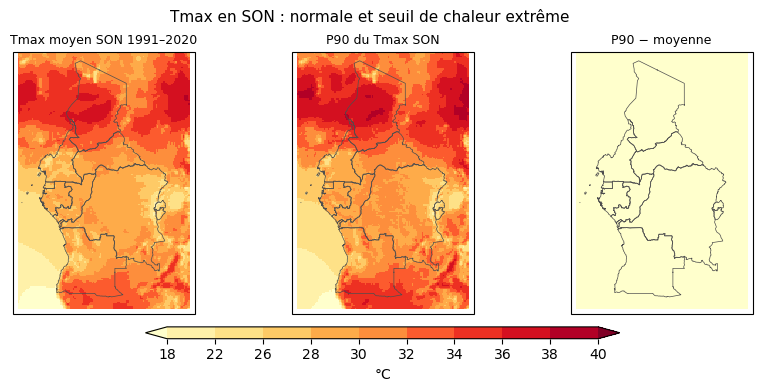

In [4]:
ntx = obs_era5.load_normals(cfg, "tmax", "0p25").sel(calendar_key="season_09")   # SON
fig = map_panel([ntx["mean"], ntx["quantile"].sel(percentile=90, method="nearest"),
                 ntx["quantile"].sel(percentile=90, method="nearest") - ntx["mean"]],
                ["Tmax moyen SON 1991–2020", "P90 du Tmax SON", "P90 − moyenne"],
                shapefile=SHP, cmap="YlOrRd", levels=[18, 22, 26, 28, 30, 32, 34, 36, 38, 40],
                extend="both", cbar_label="°C", suptitle="Tmax en SON : normale et seuil de chaleur extrême")

In [5]:
ecart = (ntx["quantile"].sel(percentile=90, method="nearest") - ntx["mean"])
print("écart P90 − moyenne du Tmax SON : médiane %.2f °C | P10 %.2f | P90 %.2f"
      % (float(ecart.median()), float(ecart.quantile(0.1)), float(ecart.quantile(0.9))))

écart P90 − moyenne du Tmax SON : médiane 0.88 °C | P10 0.51 | P90 1.43


La troisième carte montre de combien une saison doit dépasser la normale pour entrer dans les 10 % les plus chauds : moins de 1 °C dans la plupart des régions. C'est peu, ce qui rappelle que la variabilité interannuelle de la température est faible devant celle de la pluie, et que **le biais des modèles doit être corrigé finement** pour que ces seuils gardent un sens.

## 2. Deux façons de changer de grille

| Couple de grilles | Emboîtées ? | Méthode |
|---|---|---|
| CHIRPS 0,05° → 1° (C3S) | oui : 20 × 20 mailles par maille de 1° | moyenne par blocs **exacte** |
| ERA5 0,25° → 1° (C3S) | non : mailles ERA5 centrées sur les degrés entiers, mailles C3S sur les demi-degrés | remaillage **conservatif** (xESMF) |

Le remaillage conservatif attribue à chaque maille cible la moyenne des mailles sources pondérée par les surfaces communes. Le code vérifie l'emboîtement avant d'utiliser la moyenne par blocs et refuse une grille décalée.

**À noter pour la suite :** la grille NMME est elle aussi centrée sur les degrés entiers, donc décalée d'un demi-degré par rapport à C3S. Cela n'aura pas d'effet sur les produits, puisque la calibration ramènera chaque modèle sur la grille des observations (décision D3) ; cela impose seulement de ramener l'observation sur la grille de chaque modèle pour les diagnostics de skill brut.

moyenne de domaine : 0,25° 31.02 °C | 1° 31.03 °C


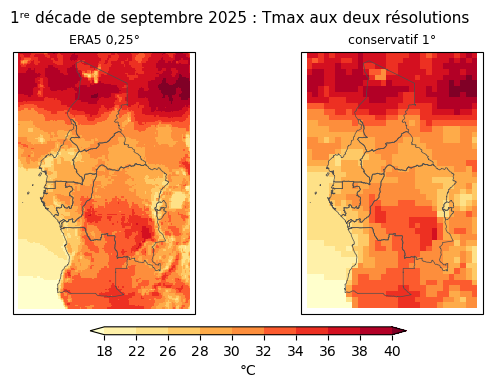

In [6]:
era5_1, _ = obs_era5.load_archives(cfg, "1p0")
d0, _ = obs_era5.load_archives(cfg, "0p25")
fig = map_panel([d0["tmax"].sel(time="2025-09-01"), era5_1["tmax"].sel(time="2025-09-01")],
                ["ERA5 0,25°", "conservatif 1°"], shapefile=SHP, cmap="YlOrRd",
                levels=[18, 22, 26, 28, 30, 32, 34, 36, 38, 40], extend="both", cbar_label="°C",
                suptitle="1ʳᵉ décade de septembre 2025 : Tmax aux deux résolutions")
w = np.cos(np.deg2rad(d0.latitude)); w1 = np.cos(np.deg2rad(era5_1.latitude))
print("moyenne de domaine : 0,25° %.2f °C | 1° %.2f °C"
      % (float(d0["tmax"].sel(time="2025-09-01").weighted(w).mean()),
         float(era5_1["tmax"].sel(time="2025-09-01").weighted(w1).mean())))

## 3. Les températures prévues par C3S

Deux sources, selon la variable :

| Variable | Jeu C3S | Échelles possibles |
|---|---|---|
| Tmax, Tmin | `seasonal-original-single-levels`, quotidien (24 h se terminant à 00 UTC) | décade, mois, saison |
| T2m moyenne | `seasonal-monthly-single-levels`, **statistiques mensuelles** | mois, saison |

Le choix des statistiques mensuelles pour la T2m moyenne (décision du 19/09/2026) évite de télécharger les champs toutes les 6 heures, soit environ 20 Go par mois d'initialisation.

**Conséquence sur les membres :** le jeu mensuel fournit l'ensemble **décalé** complet d'UKMO et de BoM, c'est-à-dire tous leurs démarrages rattachés au 1er septembre. Ces deux modèles ont donc beaucoup plus de membres en T2m qu'en Tmax, Tmin et pluie.

In [7]:
summ = pd.read_csv(c3s_totals.derived_dir(cfg) / "c3s_temperature_summary.csv")
piv = summ.pivot_table(index="centre", columns=["variable", "kind"], values="members_max")
piv.columns = [f"{v} {k}" for v, k in piv.columns]
piv.loc[[c for c in MODELS]]

,t2m forecast,t2m hindcast,tmax forecast,tmax hindcast,tmin forecast,tmin hindcast
centre,,,,,,
ecmwf,51.0,25.0,51.0,25.0,51.0,25.0
ukmo,62.0,28.0,2.0,7.0,2.0,7.0
meteo_france,51.0,31.0,51.0,31.0,51.0,31.0
dwd,50.0,30.0,50.0,30.0,50.0,30.0
cmcc,50.0,30.0,50.0,30.0,50.0,30.0
eccc,20.0,20.0,20.0,20.0,20.0,20.0
bom,121.0,27.0,11.0,3.0,11.0,3.0


### Biais des modèles bruts en température

Comparaison sur la saison SON 1993–2016, chaque modèle étant comparé à ERA5 ramené à 1° sur **les mêmes mailles et les mêmes années**.

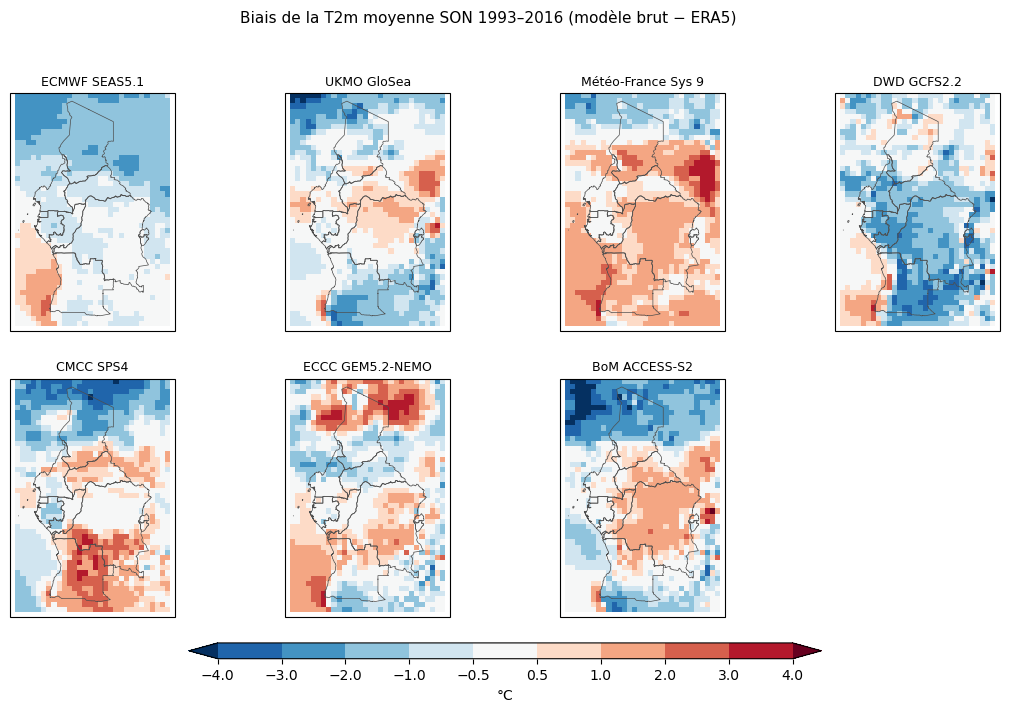

In [8]:
periods = build_periods(cfg.init_date, 181, cfg.scales)
son = [p for p in periods if p.key == "season_m0"]
years = cfg.c3s_hindcast_years
dek1, mon1 = obs_era5.load_archives(cfg, "1p0")
obs_t2m = obs_period_totals(dek1["tmean"], mon1["tmean"], son, years, how="mean").sel(period="season_m0")
obs_clim = obs_t2m.mean("year")

hc = {c: match_model_grid(c3s_totals.load_totals(cfg, c, "hindcast", "t2m").sel(period="season_m0"), obs_clim)
      for c in MODELS}
bias = {c: hc[c].mean(["year", "number"]) - obs_clim for c in MODELS}
fig = map_panel([bias[c] for c in MODELS], [LABEL[c] for c in MODELS], shapefile=SHP, cmap="RdBu_r",
                levels=[-4, -3, -2, -1, -0.5, 0.5, 1, 2, 3, 4], ncols=4, cbar_label="°C",
                suptitle="Biais de la T2m moyenne SON 1993–2016 (modèle brut − ERA5)")

In [9]:
w = np.cos(np.deg2rad(obs_clim.latitude)).broadcast_like(obs_clim)
tab = pd.DataFrame({
    "biais moyen (°C)": {LABEL[c]: float((bias[c] * w).sum() / w.sum()) for c in MODELS},
    "|biais| médian (°C)": {LABEL[c]: float(abs(bias[c]).median()) for c in MODELS},
    "écart-type interannuel modèle / ERA5": {
        LABEL[c]: float((hc[c].std("year", ddof=1).mean("number") / obs_t2m.std("year", ddof=1)).median())
        for c in MODELS},
}).round(2)
tab

,biais moyen (°C),|biais| médian (°C),écart-type interannuel modèle / ERA5
ECMWF SEAS5.1,-0.74,0.75,1.05
UKMO GloSea,-0.44,0.70,0.95
Météo-France Sys 9,0.72,1.11,1.11
DWD GCFS2.2,-0.92,1.02,1.13
CMCC SPS4,-0.11,0.91,0.99
ECCC GEM5.2-NEMO,0.25,0.79,1.00
BoM ACCESS-S2,-0.52,1.07,1.13


**Lecture.** Le biais moyen de domaine va de **−0,9 à +0,7 °C** selon le modèle, et l'écart absolu médian, qui tient compte des compensations régionales, de **0,7 à 1,1 °C**. C'est **du même ordre que la distance entre la normale et le seuil P90** mesurée en section 1 (0,88 °C en médiane). Autrement dit, un modèle trop chaud d'un degré classerait une grande partie des saisons au-dessus du seuil de chaleur extrême : pour la température, la correction de biais n'est pas un raffinement, elle conditionne le sens même des catégories.

En revanche, le rapport des écarts-types interannuels est proche de 1 pour les sept modèles (0,95 à 1,13) : **l'amplitude de la variabilité d'une année à l'autre est bien représentée**, contrairement au niveau moyen. Une correction de moyenne suffira donc probablement pour la température, là où la pluie demandera aussi un ajustement de la distribution.

## 4. NMME, second système de prévision

| Caractéristique | Valeur |
|---|---|
| Source | serveur NOAA/CPC (`International/nmme/netcdf`), les fichiers servis à CPT |
| Contenu | **moyenne d'ensemble uniquement**, pas les membres |
| Pas de temps | mensuel, donc mois et saisons seulement |
| Variables | pluie, T2m, et SST (prédicteur pour la phase P4) |

IRIDL, la source initialement prévue, s'est révélée inutilisable : délais dépassés ou modèles introuvables pour la plupart des systèmes.

In [10]:
pd.read_csv(nmme_totals.derived_dir(cfg) / "nmme_totals_summary.csv")

,model,variable,hindcast_years,n_hindcast,months,periods,last_period,missing_values
0,CFSv2,precip,1982–2025,44,10,18,AMJ 2027,11424
1,CFSv2,t2m,1982–2025,44,10,18,AMJ 2027,11424
2,NASA_GEOS5v2,precip,1982–2025,44,9,16,MAM 2027,0
3,NASA_GEOS5v2,t2m,1982–2025,44,9,16,MAM 2027,0
4,NCAR_CCSM4,precip,1982–2025,44,12,22,JJA 2027,0
5,NCAR_CCSM4,t2m,1982–2025,44,12,22,JJA 2027,0
6,CanESM5,precip,1991–2025,35,12,22,JJA 2027,0
7,CanESM5,t2m,1991–2025,35,12,22,JJA 2027,0
8,GEM5.2_NEMO,precip,1991–2025,35,12,22,JJA 2027,0
9,GEM5.2_NEMO,t2m,1991–2025,35,12,22,JJA 2027,0


Les trois modèles les plus anciens remontent à **1982**, soit 44 années de hindcast contre 24 pour C3S. C'est précisément ce que demande le draft framework (§3.2) : utiliser toute la période disponible, ce qui rend les statistiques de calibration plus robustes.

**Limite à retenir :** sans les membres, NMME ne peut pas fournir de probabilités brutes par comptage. Il entrera dans la chaîne par les méthodes fondées sur la moyenne d'ensemble (CCA, PCR, régressions), qui produiront ses probabilités calibrées.

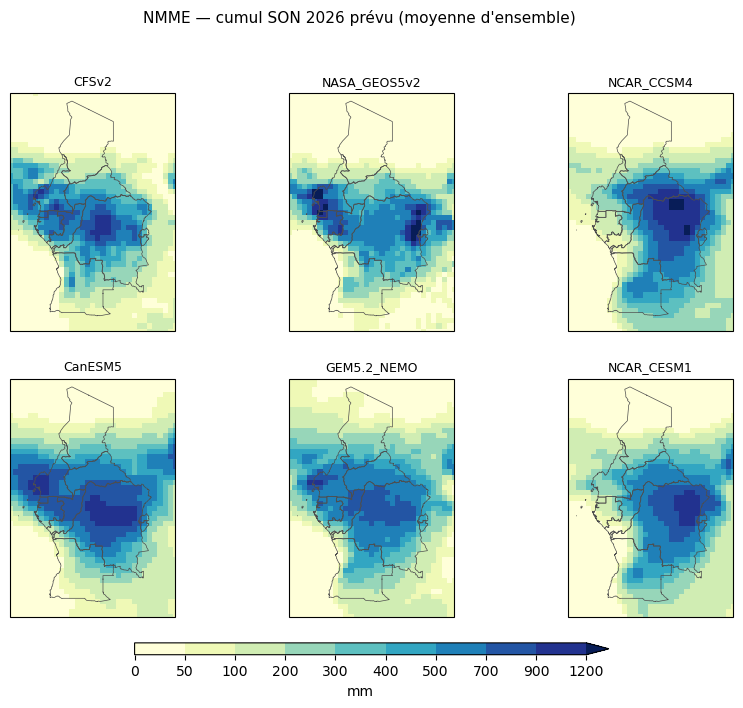

In [11]:
fc = {m: nmme_totals.load_totals(cfg, m, "precip", "forecast").sel(period="season_m0").isel(year=0)
      for m in cfg.raw["systems"]["nmme"]["models"]}
fig = map_panel(list(fc.values()), list(fc), shapefile=SHP, cmap="YlGnBu",
                levels=[0, 50, 100, 200, 300, 400, 500, 700, 900, 1200], extend="max", ncols=3,
                cbar_label="mm", suptitle="NMME — cumul SON 2026 prévu (moyenne d'ensemble)")

### Biais de NMME par rapport à CHIRPS

La grille NMME étant centrée sur les degrés entiers, CHIRPS est ramené à cette grille par remaillage conservatif (et non par moyenne par blocs, qui suppose des mailles emboîtées).

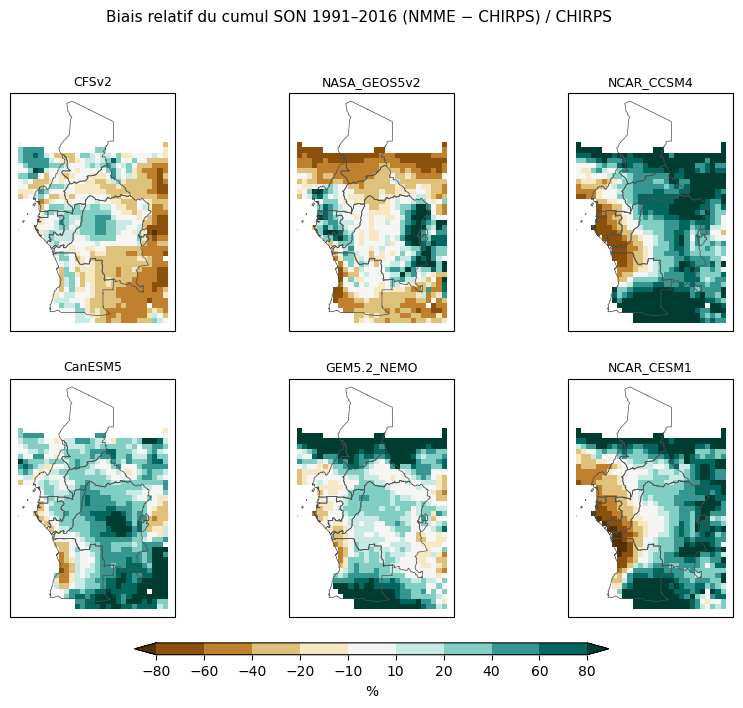

In [12]:
dekc, monc = obs_chirps.load_archives(cfg, "p05")
obs_son_nmme = xr.concat([conservative_to_degree(
    obs_period_totals(dekc, monc, son, [y]).sel(period="season_m0", year=y).load(), 1.0, target_offset=0.0)
    for y in range(1991, 2017)], dim=pd.Index(range(1991, 2017), name="year"))
obs_c = obs_son_nmme.mean("year")

nm = {m: nmme_totals.load_totals(cfg, m, "precip", "hindcast").sel(period="season_m0")
      for m in cfg.raw["systems"]["nmme"]["models"]}
bias_n = {m: ((v.sel(year=slice(1991, 2016)).mean("year").sel(latitude=obs_c.latitude, longitude=obs_c.longitude)
               - obs_c) / obs_c.where(obs_c > 50) * 100) for m, v in nm.items()}
fig = map_panel(list(bias_n.values()), list(bias_n), shapefile=SHP, cmap="BrBG",
                levels=[-80, -60, -40, -20, -10, 10, 20, 40, 60, 80], ncols=3, cbar_label="%",
                suptitle="Biais relatif du cumul SON 1991–2016 (NMME − CHIRPS) / CHIRPS")

## 5. Bilan de la phase P1

| Source | Variables | Échelles | Période |
|---|---|---|---|
| C3S, 7 modèles | pluie, Tmax, Tmin | décade, mois, saison | hindcast 1993–2016 + prévision 2026 |
| C3S, 7 modèles | T2m moyenne | mois, saison | idem |
| NMME, 6 modèles | pluie, T2m (moyenne d'ensemble) | mois, saison | depuis 1982 ou 1991 |
| CHIRPS | pluie | décade, mois, saison | 1981–2025 |
| ERA5 | T moyenne, Tmax, Tmin | décade, mois, saison | 1981–2026 |

Les normales 1991–2020 par point de grille sont disponibles pour la pluie et pour les trois variables de température : ce sont les seuils communs de toutes les catégories (décision D12) et les percentiles extrêmes des produits de température (D13).

**Phase suivante (P2) :** mesurer le **skill brut** de chaque modèle, sur chaque échelle et chaque échéance. C'est la référence que la calibration devra battre.